In [1]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             52 bits physical, 57 bits virtual
  Byte Order:                Little Endian
CPU(s):                      192
  On-line CPU(s) list:       0-191
Vendor ID:                   AuthenticAMD
  Model name:                AMD EPYC 9684X 96-Core Processor
    CPU family:              25
    Model:                   17
    Thread(s) per core:      1
    Core(s) per socket:      96
    Socket(s):               2
    Stepping:                2
    Frequency boost:         enabled
    CPU(s) scaling MHz:      69%
    CPU max MHz:             3715.4290
    CPU min MHz:             1500.0000
    BogoMIPS:                5099.89
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ht s
                             yscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constan
                         

In [2]:
import numpy as np
import pickle
import time
import glob

import sys
sys.path.insert(0, "../..")
from shared import load_sweep_data, run_param_recovery, plot_param_estimate, setup_latex_matplotlib

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"delta_grad == 0\.0\. Check if the approximated function is linear\..*",
    category=UserWarning,
)

In [4]:
all_data, data_keys = load_sweep_data("kappa")

Loaded 10 kappa values from addm_data_all_kappa_20260220-230703.pkl


In [5]:
num_data_list = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]

### Run maximum likelihood with aDDM likelihood function with different dataset size

In [6]:
paras_true, paras_mle = run_param_recovery(all_data, num_data_list, mode="mle")

true params: [0.30, 0.10, 2.00, 0.50]
num_data:   100, mle: [0.73476, 0.16054, 2.21906, 0.68829]
num_data:   200, mle: [0.91079, 0.12732, 2.11426, 0.58729]
num_data:   400, mle: [0.43930, 0.12362, 2.02641, 0.45312]
num_data:   800, mle: [0.48319, 0.11611, 2.05545, 0.50900]
num_data:  1600, mle: [0.35398, 0.10609, 2.01747, 0.52243]
num_data:  3200, mle: [0.31045, 0.10851, 2.01383, 0.53255]
num_data:  6400, mle: [0.32565, 0.10033, 2.00264, 0.51455]
num_data: 12800, mle: [0.29240, 0.10222, 2.00148, 0.50538]
num_data: 25600, mle: [0.29977, 0.10364, 2.00683, 0.50596]

true params: [0.30, 0.20, 2.00, 0.50]
num_data:   100, mle: [0.40781, 0.26373, 2.11299, 0.59095]
num_data:   200, mle: [0.36802, 0.22799, 2.04908, 0.59494]
num_data:   400, mle: [0.38146, 0.23164, 2.01334, 0.53688]
num_data:   800, mle: [0.28152, 0.21150, 1.99411, 0.51280]
num_data:  1600, mle: [0.36622, 0.20627, 2.03173, 0.56559]
num_data:  3200, mle: [0.33714, 0.20018, 2.00380, 0.53158]
num_data:  6400, mle: [0.32724, 0.1952

### Run maximum likelihood with TADA likelihood function with different dataset size

In [7]:
_, paras_tada = run_param_recovery(all_data, num_data_list, mode="tada")

true params: [0.30, 0.10, 2.00, 0.50]
num_data:   100, tada mle: [1.18412, 0.13329, 2.22017, 0.70107]
num_data:   200, tada mle: [0.99520, 0.12267, 2.11387, 0.58778]
num_data:   400, tada mle: [0.34242, 0.13184, 2.02226, 0.45333]
num_data:   800, tada mle: [0.36057, 0.12619, 2.05327, 0.51066]
num_data:  1600, tada mle: [0.18673, 0.12060, 2.01530, 0.52319]
num_data:  3200, tada mle: [0.13815, 0.12501, 2.01110, 0.53077]
num_data:  6400, tada mle: [0.16999, 0.11392, 1.99996, 0.51321]
num_data: 12800, tada mle: [0.15467, 0.11481, 1.99832, 0.50336]
num_data: 25600, tada mle: [0.18939, 0.11347, 2.00308, 0.50358]

true params: [0.30, 0.20, 2.00, 0.50]
num_data:   100, tada mle: [0.19221, 0.30686, 2.10353, 0.58539]
num_data:   200, tada mle: [0.23653, 0.24905, 2.04021, 0.59326]
num_data:   400, tada mle: [0.37315, 0.23177, 2.00115, 0.53017]
num_data:   800, tada mle: [0.21332, 0.22262, 1.97813, 0.50381]
num_data:  1600, tada mle: [0.27311, 0.22096, 2.02148, 0.55649]
num_data:  3200, tada mle: 

num_data: 25600, tada mle: [0.14103, 0.34253, 1.98856, 0.48968]

true params: [0.30, 0.40, 2.00, 0.50]
num_data:   100, tada mle: [0.08307, 0.54203, 1.82304, 0.40885]
num_data:   200, tada mle: [0.20480, 0.52851, 1.94807, 0.50266]
num_data:   400, tada mle: [0.14820, 0.48575, 1.95782, 0.48479]
num_data:   800, tada mle: [0.08412, 0.48840, 1.97344, 0.46014]
num_data:  1600, tada mle: [0.13018, 0.47552, 1.99538, 0.49229]
num_data:  3200, tada mle: [0.14900, 0.45992, 1.99470, 0.49810]
num_data:  6400, tada mle: [0.12919, 0.45169, 1.99176, 0.51388]
num_data: 12800, tada mle: [0.12598, 0.45135, 1.99160, 0.48957]
num_data: 25600, tada mle: [0.13275, 0.44936, 1.99008, 0.49032]

true params: [0.30, 0.50, 2.00, 0.50]
num_data:   100, tada mle: [0.13023, 0.52025, 2.13637, 0.42396]
num_data:   200, tada mle: [0.17033, 0.55652, 2.11347, 0.52747]
num_data:   400, tada mle: [0.15335, 0.56372, 2.12170, 0.48701]
num_data:   800, tada mle: [0.14906, 0.59860, 2.07801, 0.51348]
num_data:  1600, tada mle:

In [8]:
# data_to_save = {
#     "paras_true_arr": paras_true,
#     "paras_mle_arr": paras_mle,
#     "paras_tada_arr": paras_tada,
# }
# fname = "tada_mle_result_" + time.strftime("%Y%m%d-%H%M%S") + ".pkl"
# with open(fname, "wb") as f:
#     pickle.dump(data_to_save, f)
# print(f"Saved to {fname}")

In [9]:
# # load results (if necessary)
# result_files = sorted(glob.glob("tada_mle_result_*.pkl"))
# results = pickle.load(open(result_files[-1], "rb"))
# paras_true = results["paras_true_arr"]
# paras_mle = results["paras_mle_arr"]
# paras_tada = results["paras_tada_arr"]

In [10]:
setup_latex_matplotlib()

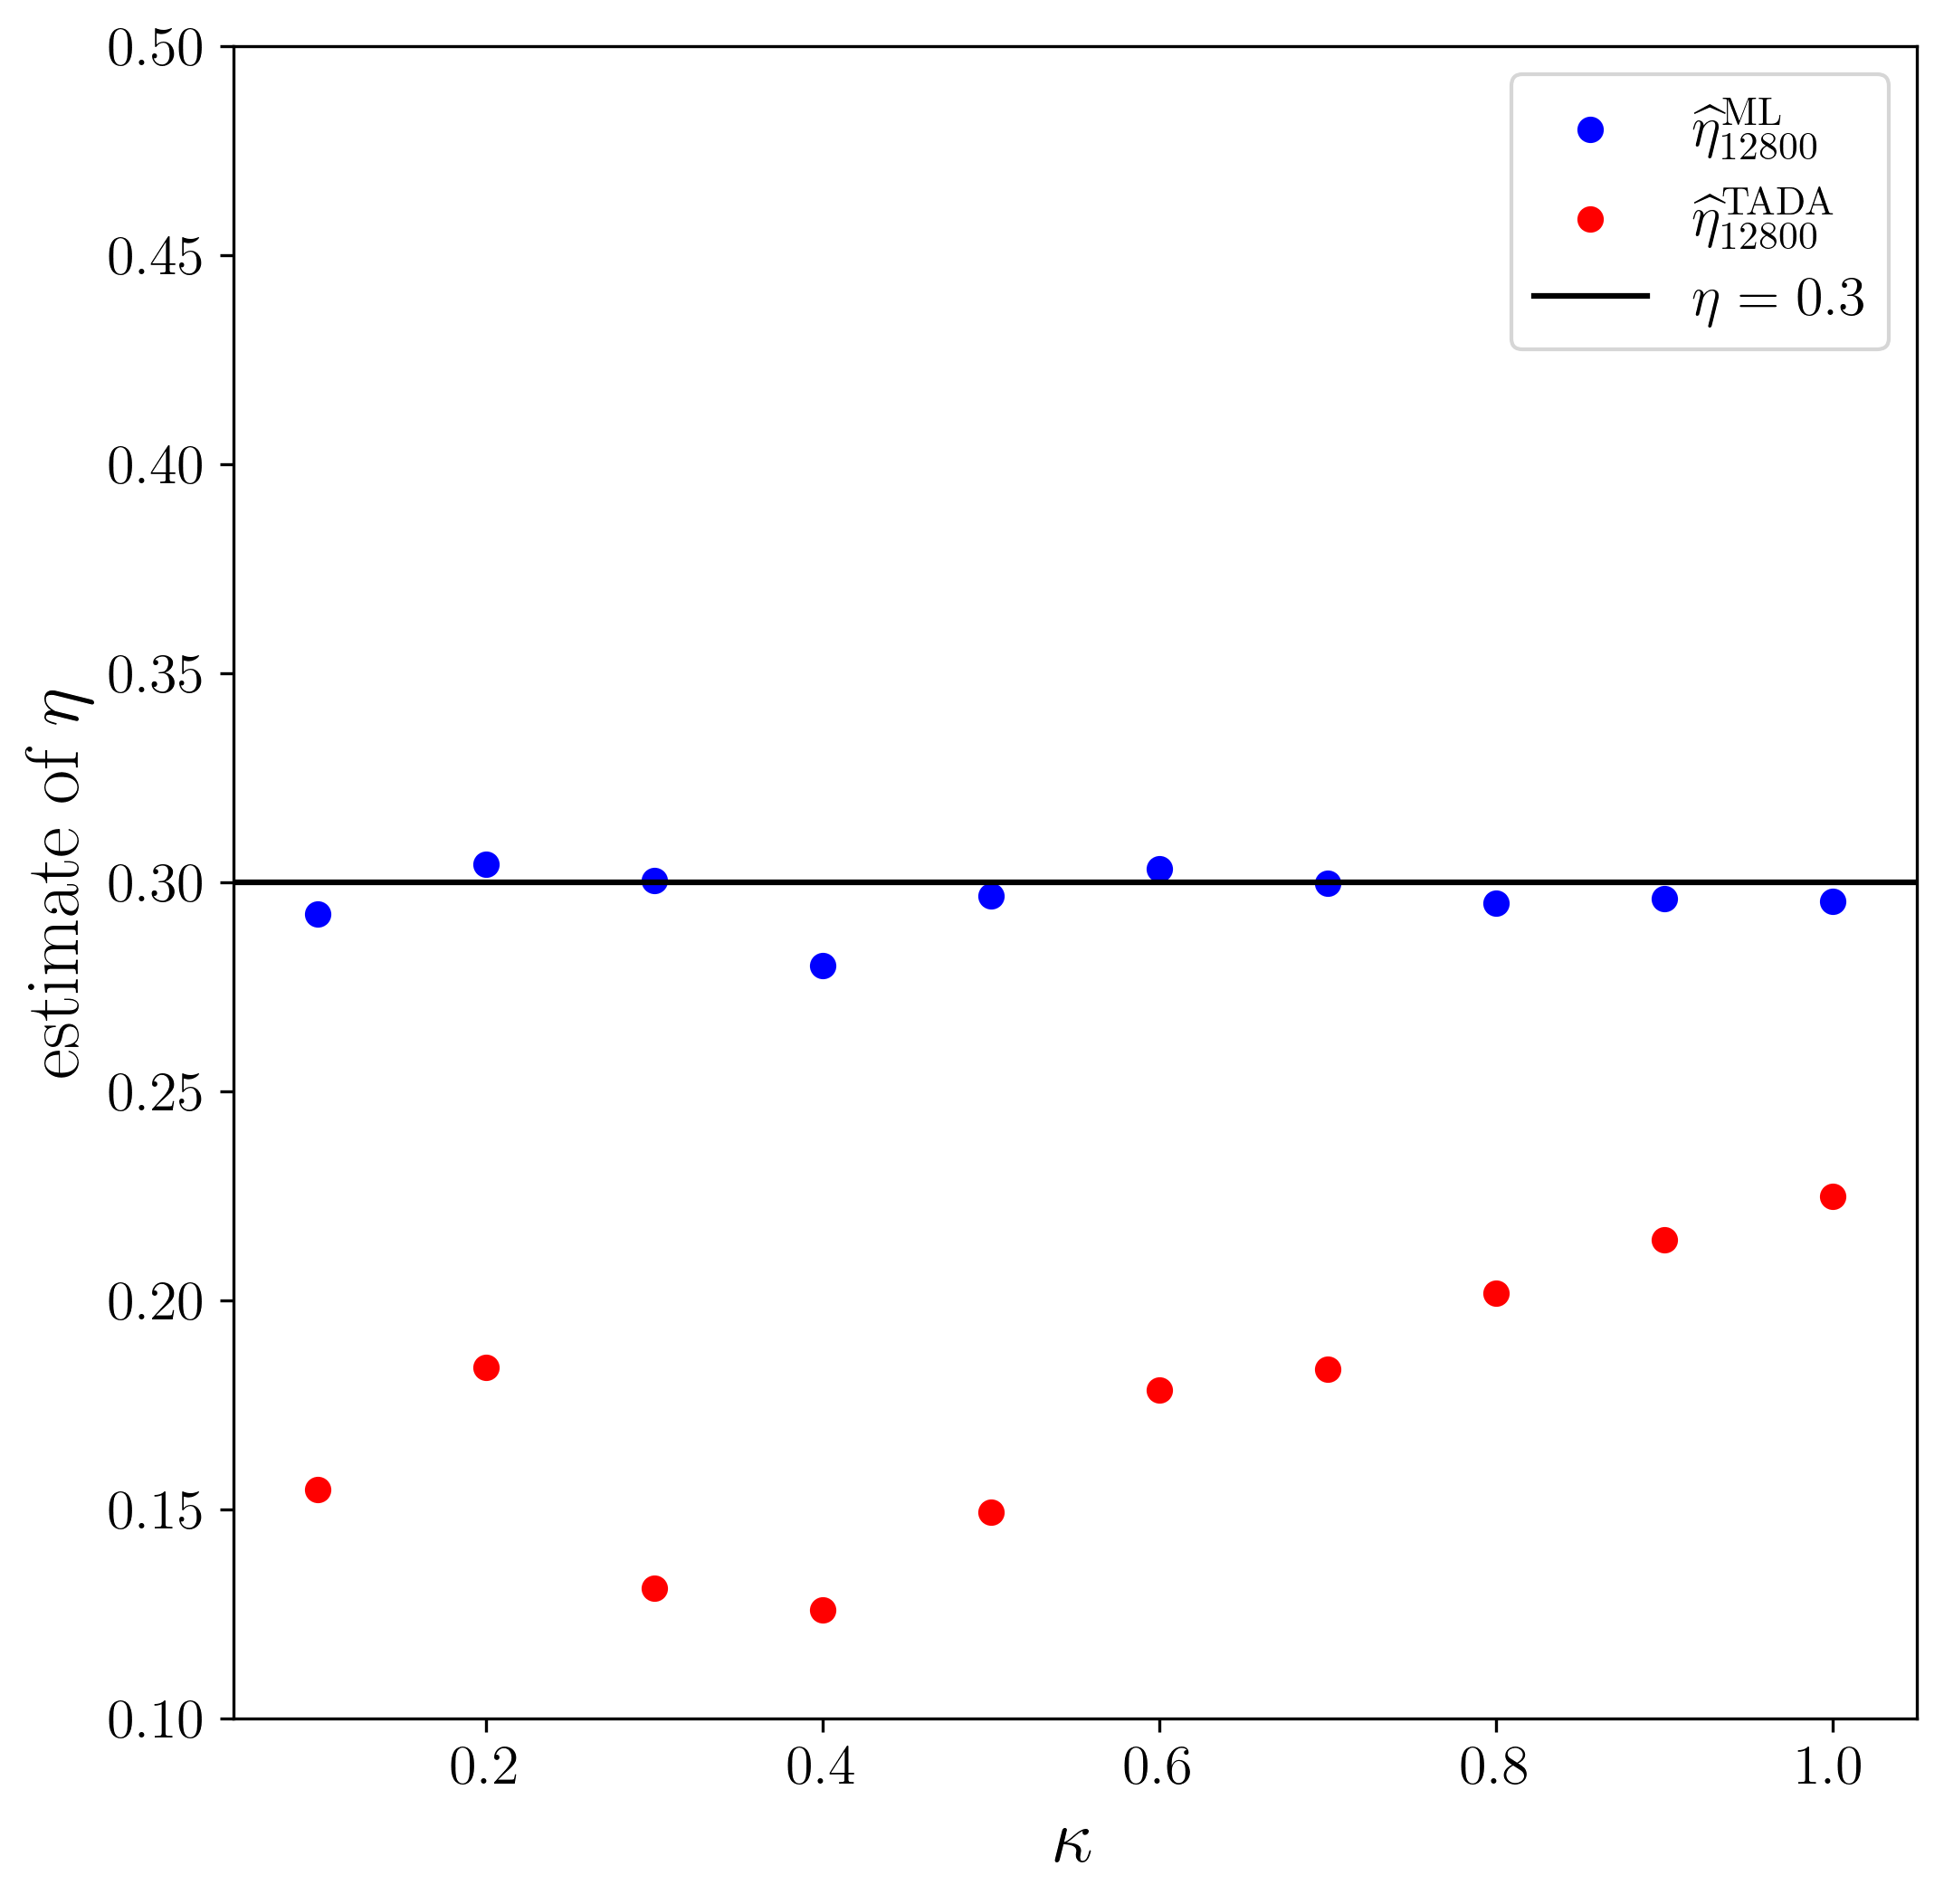

In [11]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=0, param_name=r"\eta",
    swept_idx=1, swept_name=r"\kappa",
    num_data_list=num_data_list,
    horizontal_line=paras_true[-2, 0, 0],
    xlim=(0.05, 1.05), ylim=(0.1, 0.5),
)

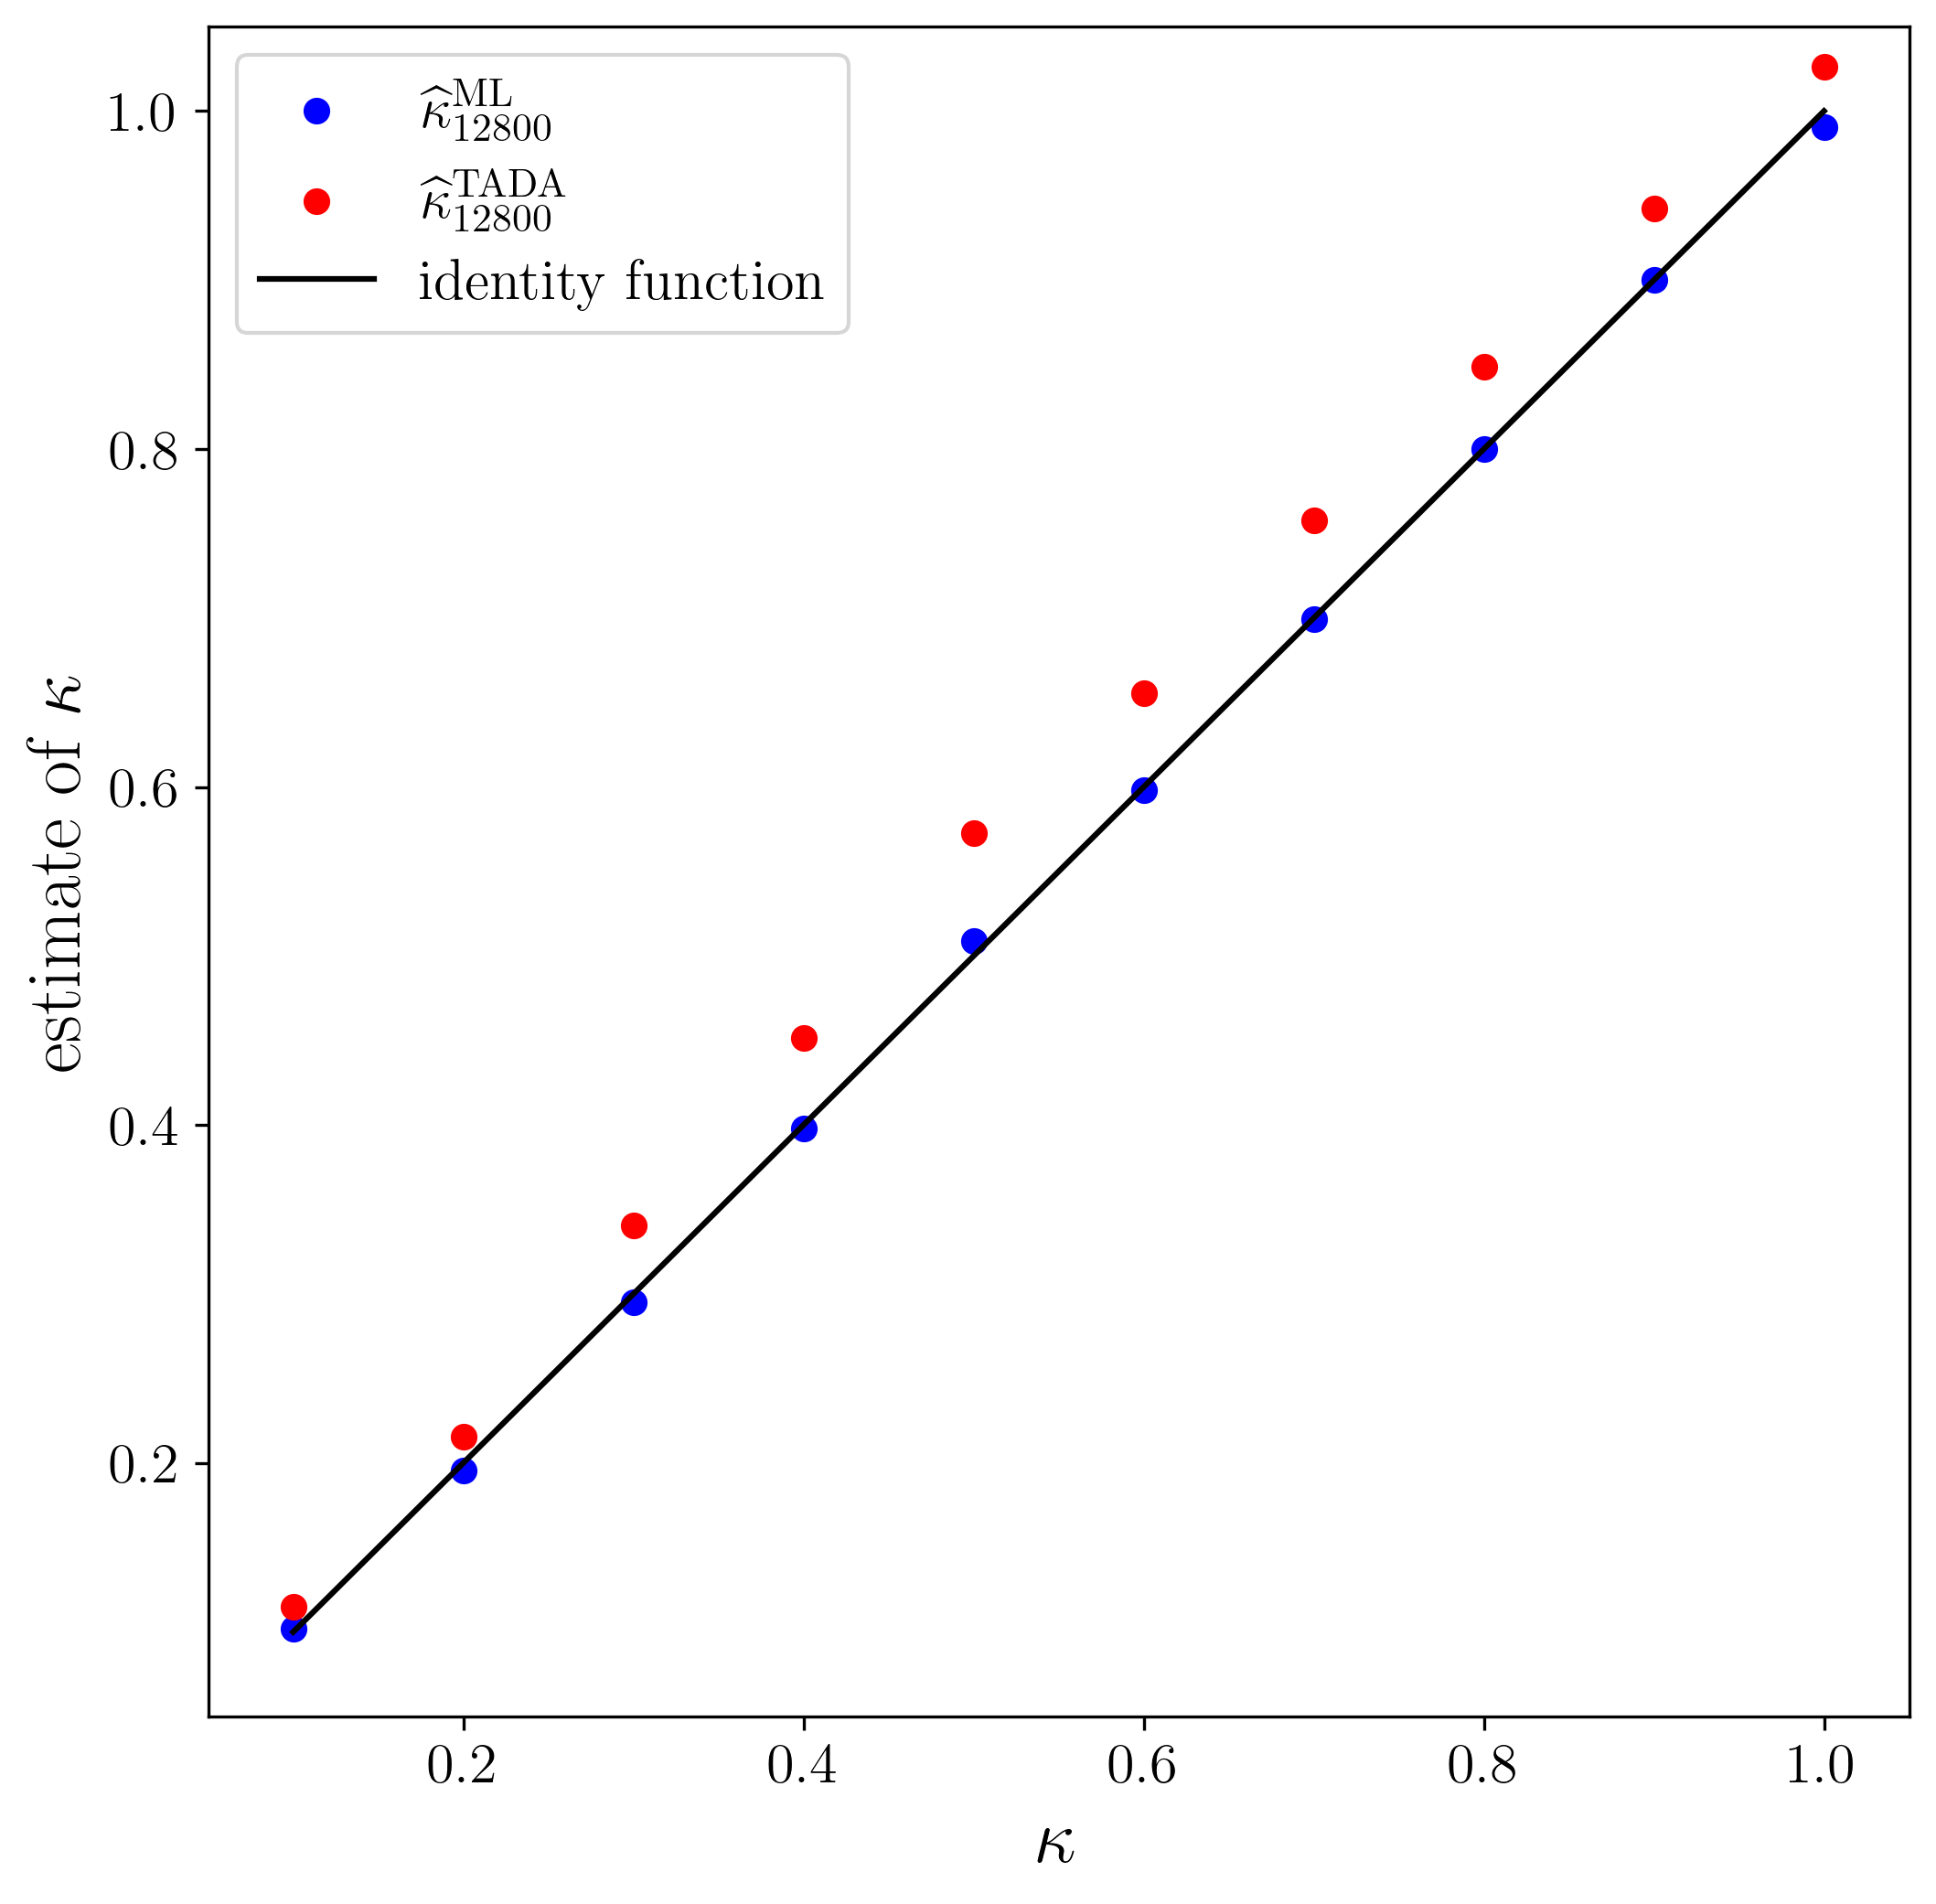

In [12]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=1, param_name=r"\kappa",
    swept_idx=1, swept_name=r"\kappa",
    num_data_list=num_data_list,
    identity_line=True,
    xlim=(0.05, 1.05), ylim=(0.05, 1.05),
)

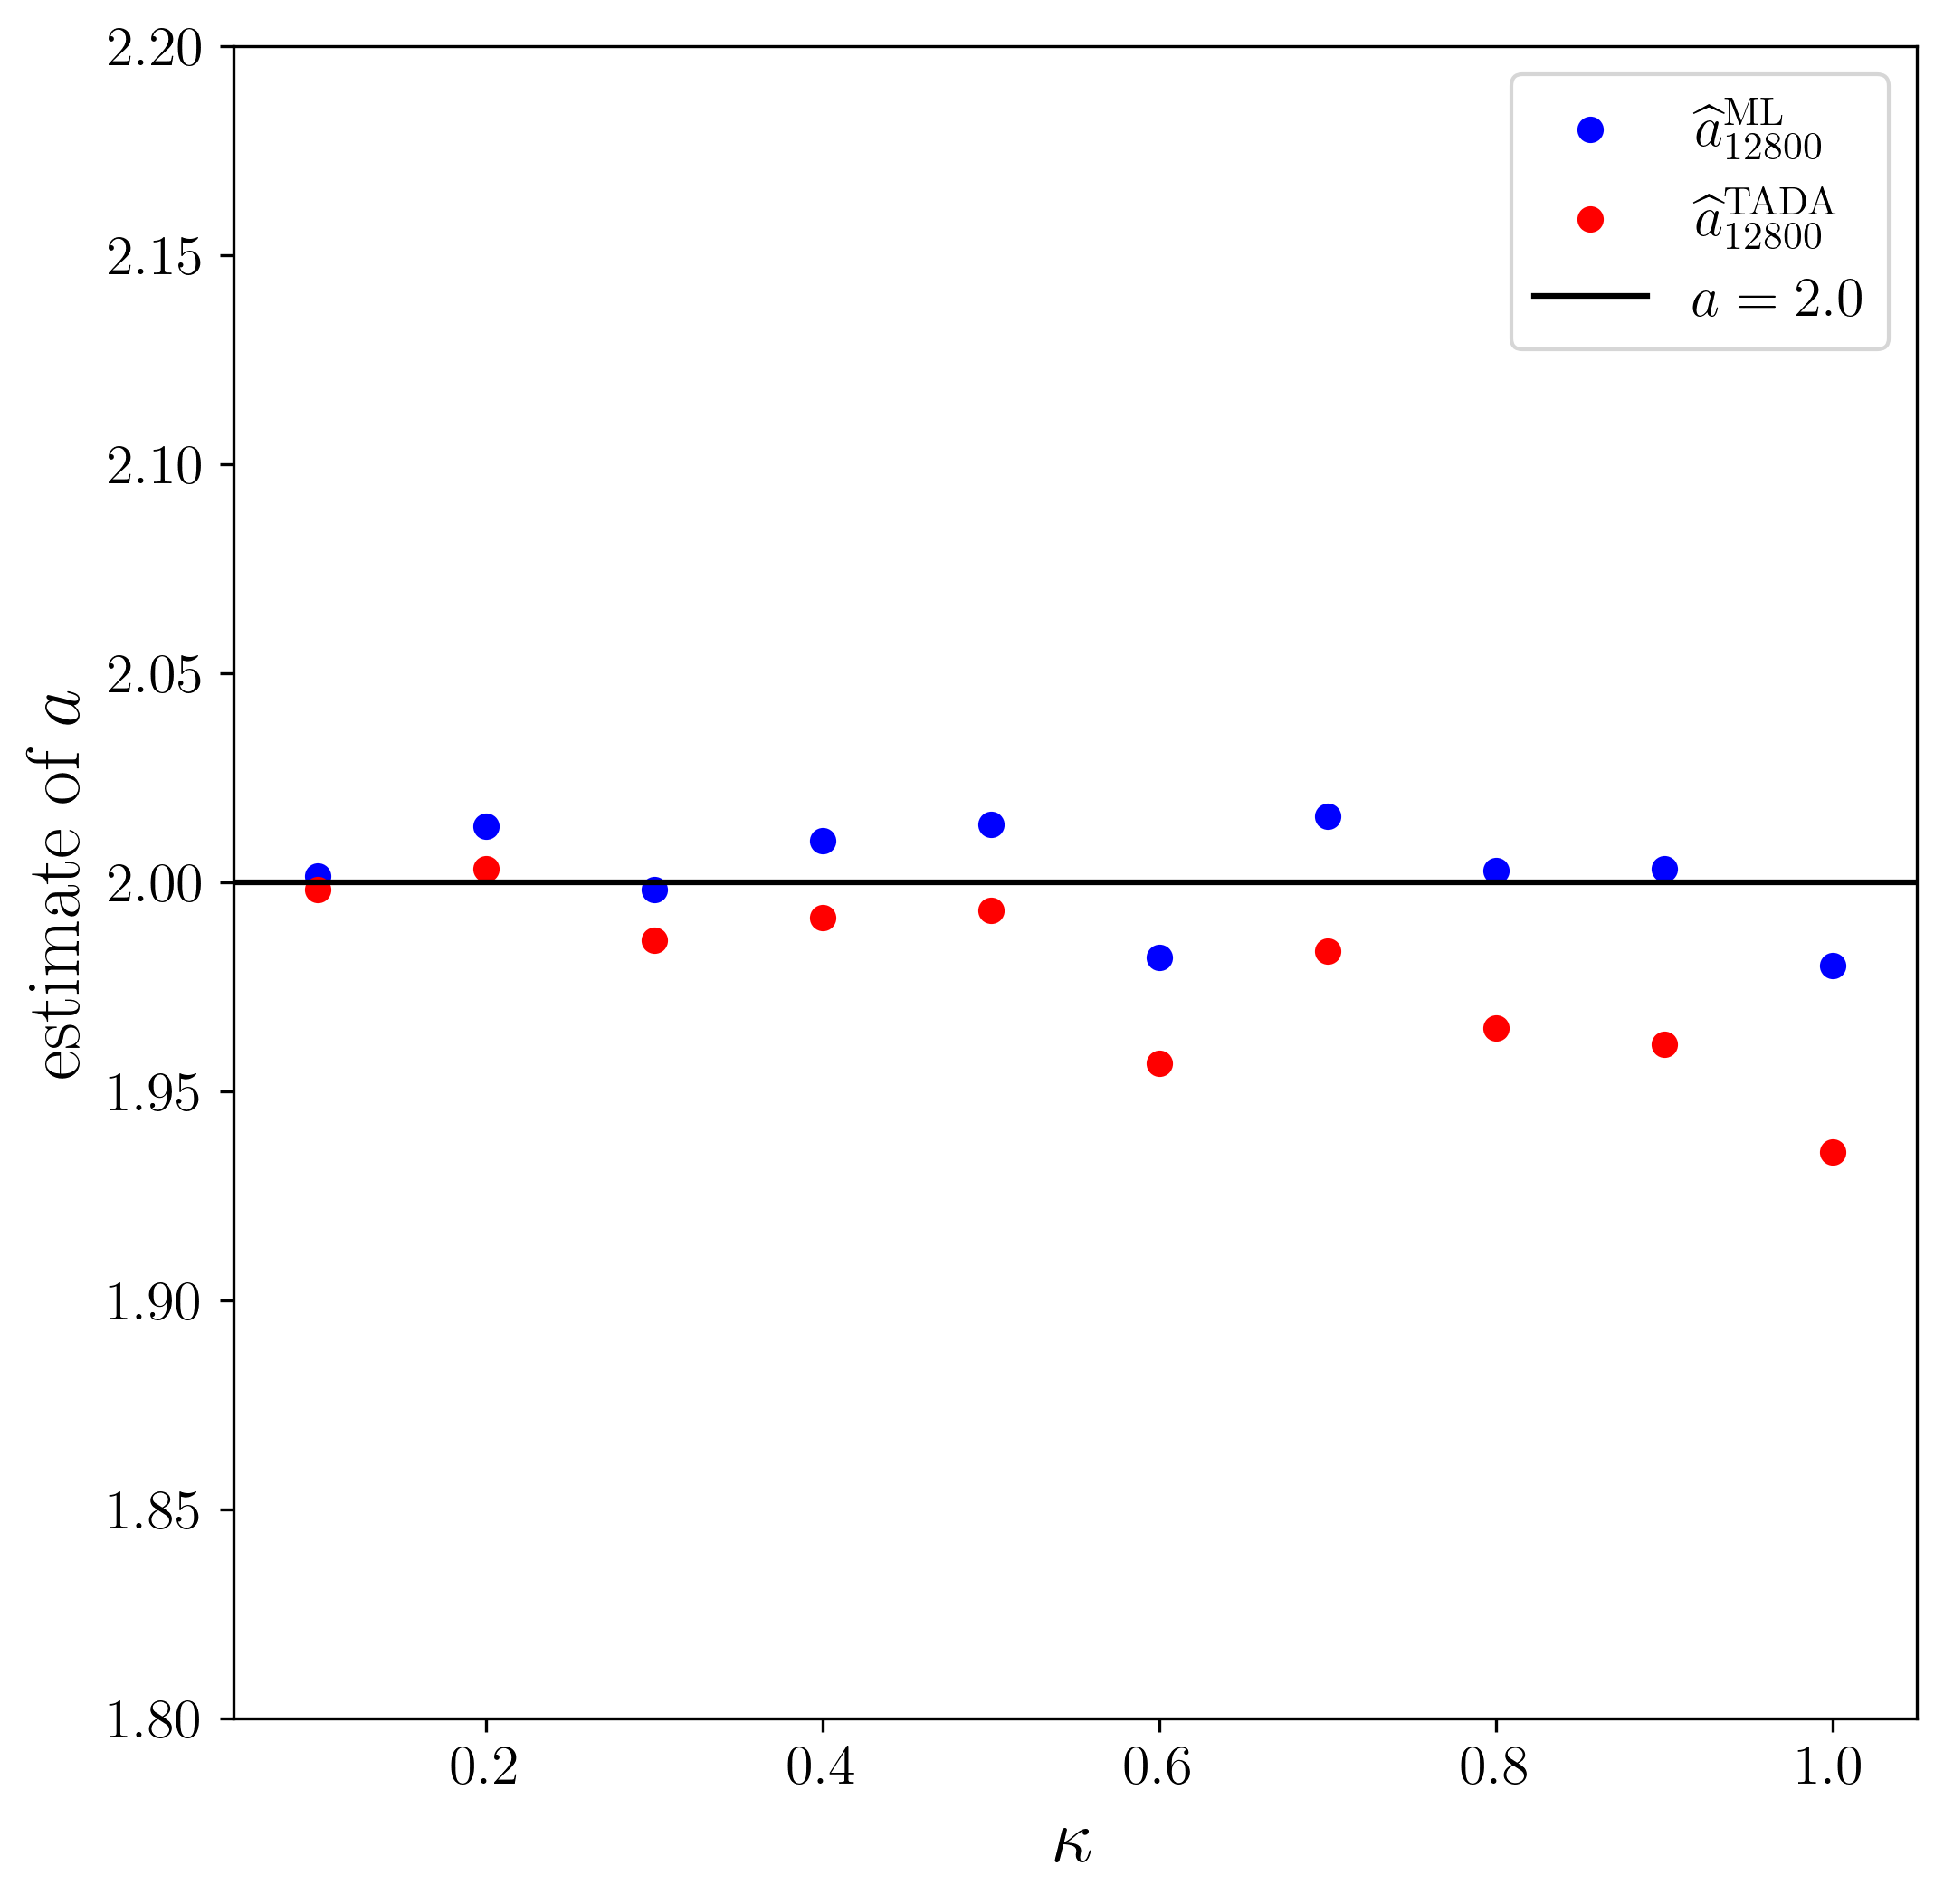

In [13]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=2, param_name=r"a",
    swept_idx=1, swept_name=r"\kappa",
    num_data_list=num_data_list,
    horizontal_line=paras_true[-2, 0, 2],
    xlim=(0.05, 1.05), ylim=(1.8, 2.2),
)

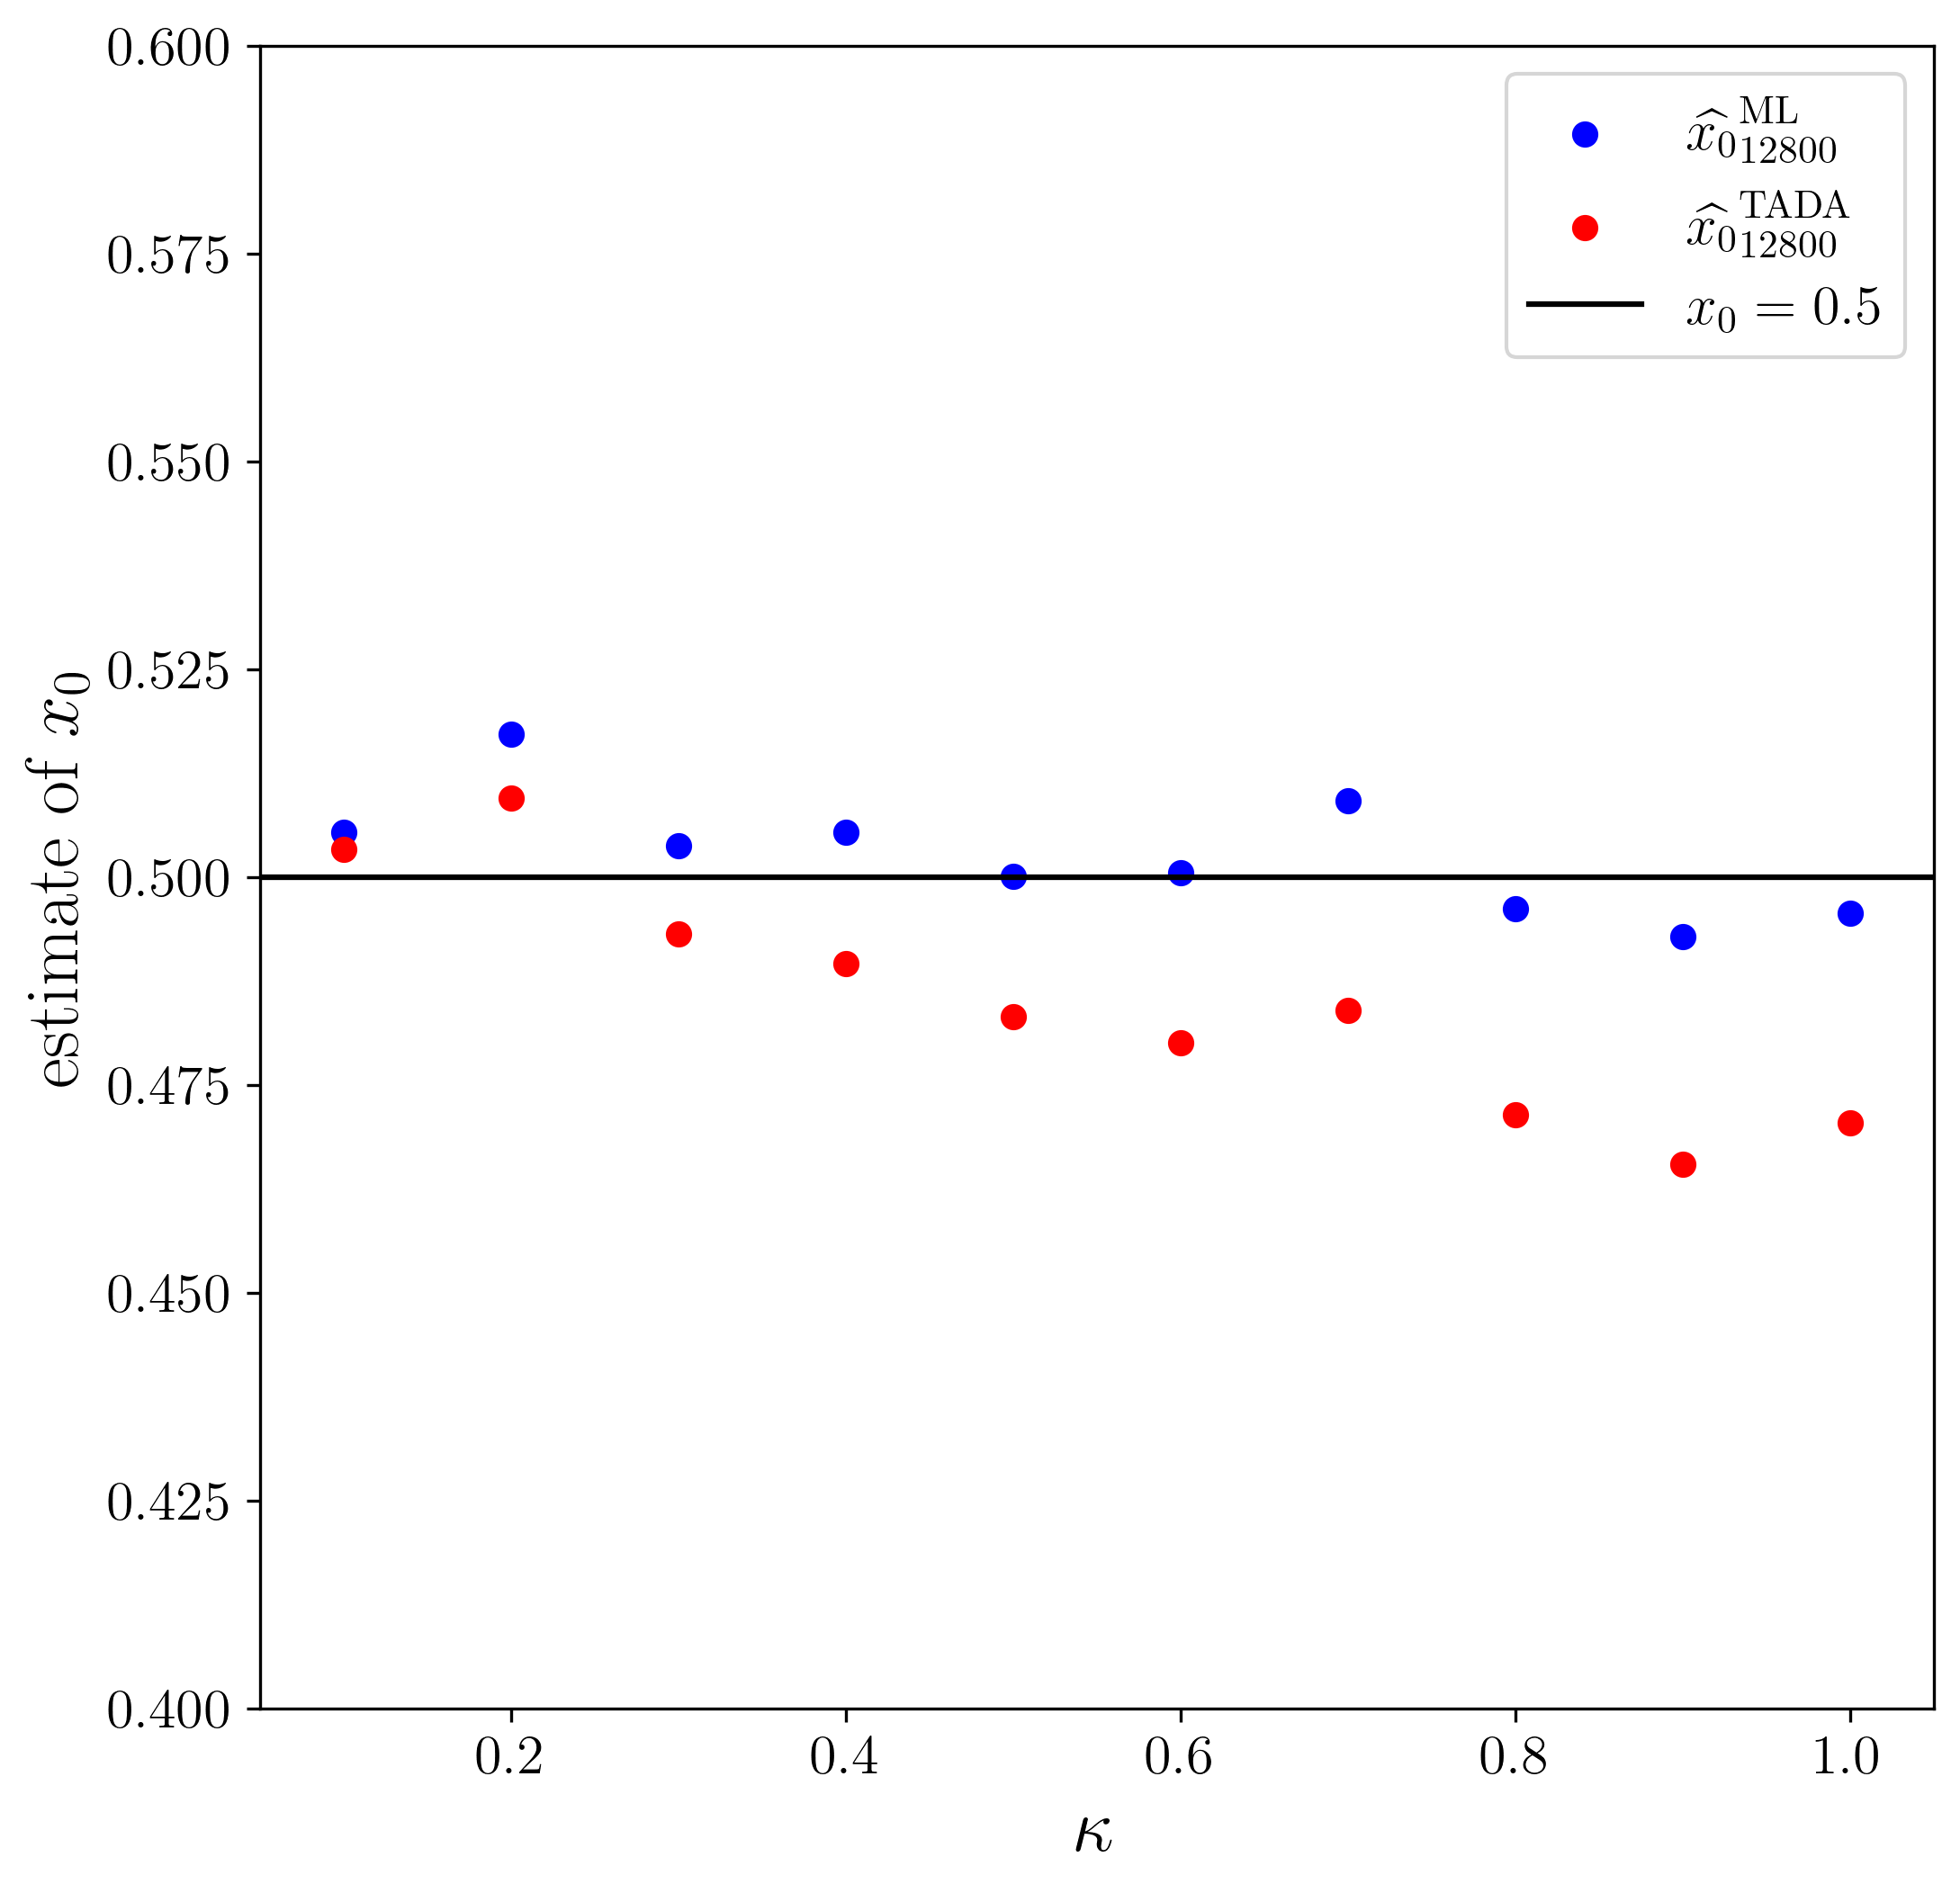

In [14]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=3, param_name=r"x_0",
    swept_idx=1, swept_name=r"\kappa",
    num_data_list=num_data_list,
    horizontal_line=paras_true[-2, 0, 3],
    xlim=(0.05, 1.05), ylim=(0.4, 0.6),
)